# Импорт библиотек

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from skopt import BayesSearchCV

# Код из 4 лабы

In [22]:
path = r"F:\\VSCODE_PROJECT\\ML_Proga\\LAB_3\\smartphone_battery_processed.csv"
df = pd.read_csv(path)
target = "Battery_Drop_Per_Hour"
cols_to_keep = [
    "App_Running",
    "Screen_On_Time_min",
    "CPU_Usage_%",
    "Battery_Temperature_C",
    target,
    "Network_Type",
    "Brightness_Level_%",
    "RAM_Usage_MB",
    "Charging_State",
    "Usage_Mode",
    "Intensity",
    "High_Temperature",
]
df = df[cols_to_keep]
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_cols = ["App_Running", "Network_Type", "Charging_State", "Usage_Mode"]
num_cols = ["Screen_On_Time_min", "Battery_Temperature_C", "Intensity", "High_Temperature"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[cat_cols])
scaler = StandardScaler().fit(X_train[num_cols])
def transform_data(data):
    cat = pd.DataFrame(ohe.transform(data[cat_cols]), columns=ohe.get_feature_names_out(), index=data.index)
    num = pd.DataFrame(scaler.transform(data[num_cols]), columns=num_cols, index=data.index)
    return pd.concat([num, cat], axis=1)
X_train_f = transform_data(X_train)
X_test_f = transform_data(X_test)

# Вывод корреляций 

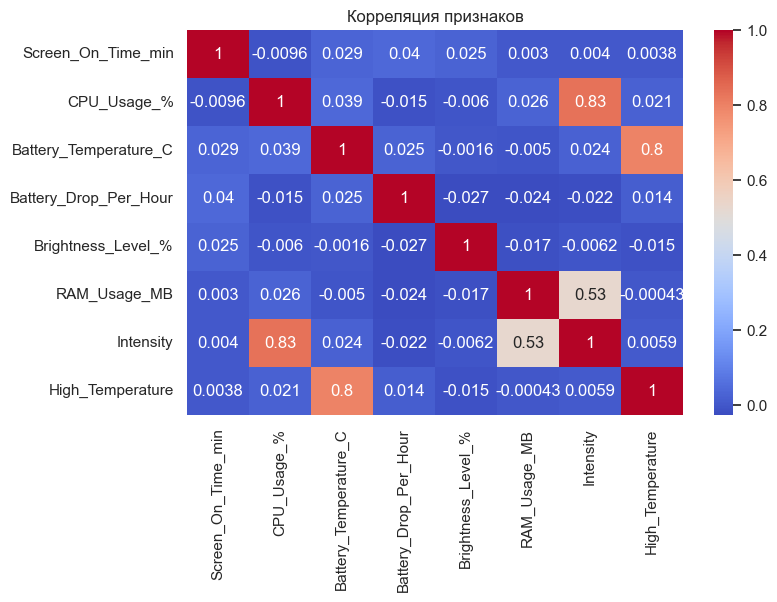

In [23]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

# Лабораторная номер 5

Параметры для поиска

In [24]:
#для Байесовского поиска
search_spaces = {
    "n_estimators": [100, 200, 300],
    "learning_rate": (0.01, 0.1),
    "max_depth": [3, 5, 7, 10],
    "subsample": (0.6, 1.0),
}

# для Grid и Random Search
simple_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0],
}

Функция для поиска параметров

In [25]:
results_list = []


def run_experiment(name, search_obj):
    start_time = time.time()
    search_obj.fit(X_train_f, y_train)
    end_time = time.time() - start_time

    best_model = search_obj.best_estimator_
    y_pred = best_model.predict(X_test_f)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results_list.append(
        {
            "Method": name,
            "Time_sec": end_time,
            "R2": r2,
            "MSE": mse,
            "MAE": mae,
            "Best_Params": search_obj.best_params_,
        }
    )
    print(f"Время: {end_time:.2f}с")

Поиск решёткой

In [26]:
run_experiment(
    "Grid Search",
    GridSearchCV(
        XGBRegressor(random_state=42), simple_param_grid, cv=3, n_jobs=-1, scoring="r2"
    ),
)


Время: 28.02с


Случайный поиск

In [27]:
run_experiment(
    "Random Search",
    RandomizedSearchCV(
        XGBRegressor(random_state=42),
        simple_param_grid,
        n_iter=15,
        cv=3,
        n_jobs=-1,
        scoring="r2",
        random_state=42,
    ),
)

Время: 1.91с


Байсовский метод

In [28]:
run_experiment(
    "Bayesian Search",
    BayesSearchCV(
        XGBRegressor(random_state=42),
        search_spaces,
        n_iter=15,
        cv=3,
        n_jobs=-1,
        scoring="r2",
        random_state=42,
    ),
)

Время: 10.97с


Вывод метрик

In [29]:
df_res = pd.DataFrame(results_list)

for index, row in df_res.iterrows():
    print(f"\nМетод: {row['Method']}")
    print(f"Лучший R2: {row['R2']:.4f}")
    print(f"MSE: {row["MSE"]}")
    print(f"MAE: {row["MAE"]}")
    print(f"Время поиска {row["Time_sec"]}")
    print("Параметры")
    for param, value in row["Best_Params"].items():
        print(f"  {param}: {value}")



Метод: Grid Search
Лучший R2: 0.0020
MSE: 24.672705885897525
MAE: 3.977718310235801
Время поиска 28.021400690078735
Параметры
  learning_rate: 0.01
  max_depth: 5
  n_estimators: 100
  subsample: 0.6

Метод: Random Search
Лучший R2: 0.0022
MSE: 24.66748107971604
MAE: 3.974395745044535
Время поиска 1.9097273349761963
Параметры
  subsample: 0.6
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.01

Метод: Bayesian Search
Лучший R2: 0.0020
MSE: 24.672705885897525
MAE: 3.977718310235801
Время поиска 10.966686010360718
Параметры
  learning_rate: 0.01
  max_depth: 5
  n_estimators: 100
  subsample: 0.6


График метрик и методов

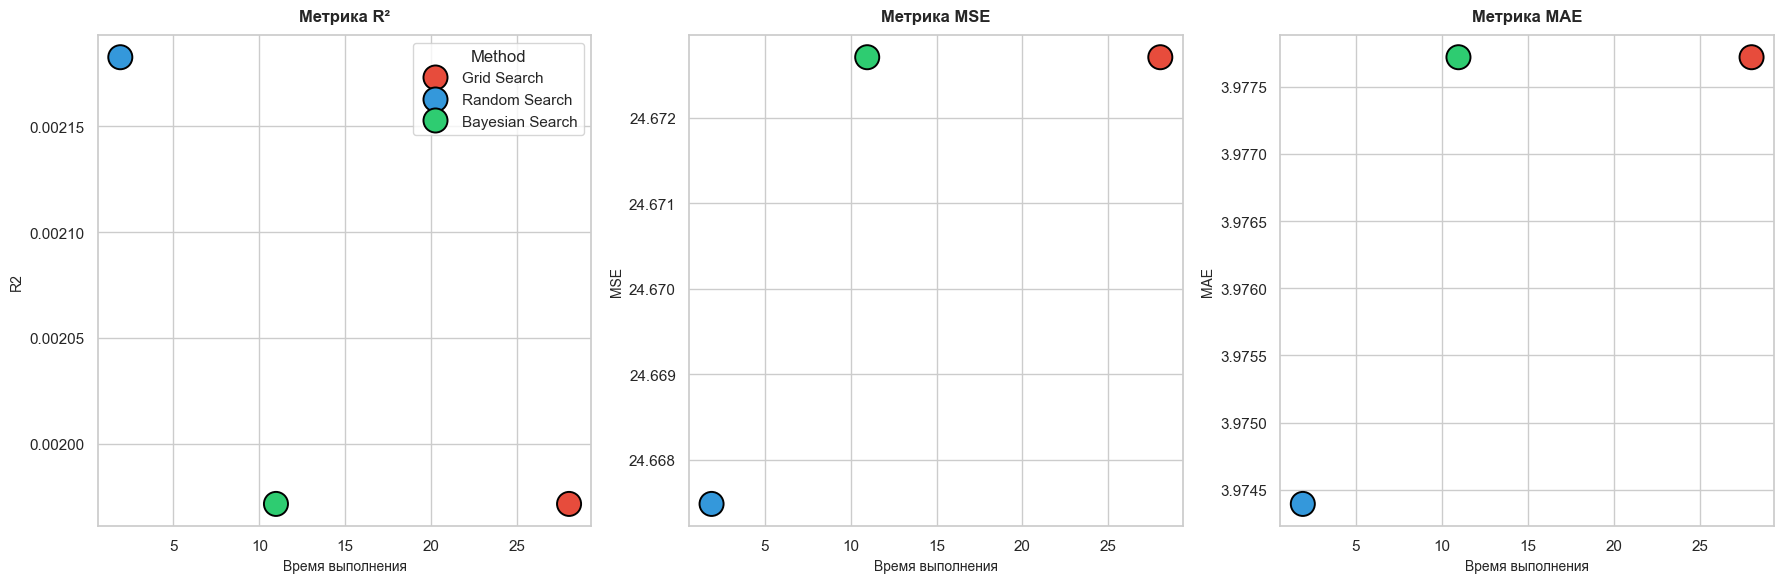

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['R2', 'MSE', 'MAE']
titles = [
    'Метрика R²',
    'Метрика MSE',
    'Метрика MAE'
]

for i, ax in enumerate(axes):
    metric = metrics[i]

    # Строим точки
    sns.scatterplot(
        data=df_res,
        x='Time_sec',
        y=metric,
        hue='Method',
        s=300,
        ax=ax,
        palette=['#e74c3c', '#3498db', '#2ecc71'],
        edgecolor='black',
        legend=(i==0)
    )

    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Время выполнения', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)

plt.tight_layout()
plt.show()